In [1]:
from utils import * 
from files.pdb import PDBFile
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass, asdict
import shutil 
from matplotlib.lines import Line2D

%load_ext autoreload 
%autoreload 2

In [2]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]

In [3]:
# Interested in looking at potential protein-protein interactions, particularly potential interactions with the ATPase as a possible hint at function. 

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id != 'bz_12'].copy()
genes_df['alphafold_gene_id'] = genes_df.apply(lambda row : f'{row.genome_id}_cluster_{int(row.cluster_id)}_1mer', axis=1)
genes_df = genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].copy()

FASTAFile.from_df(genes_df).write('../data/genes/level_1_conserved_clusters.faa')

In [17]:
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.
# ALPHAFOLD_BIOTITE_CMD = 'sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/{file_name} --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"'
ALPHAFOLD_BIOTITE_CMD = 'sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir /root/af_input --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"'
ALPHAFOLD_METADATA_PATH = '../data/genes/alphafold/alphafold_metadata_07_21_2026.csv'

In [5]:
if not os.path.exists(ALPHAFOLD_METADATA_PATH):
    alphafold_metadata_df = list()

    for dir_path in tqdm(glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')), desc='Processing AlphaFold output...'):
        output = AlphaFoldOutput(dir_path)

        info = dict()
        info['name'] = output.name 
        info['dir_path'] = os.path.abspath(dir_path)
        info['iptm'] = json.dumps(output.get_iptms())
        info['ptm'] = json.dumps(output.get_ptms())

        for msas in output.get_msas():
            for msa_type, msa in msas.items():
                msa = MSA.from_string(msa)
                info['msa_type'] = msa_type 
                info['msa_num_sequences'] = len(msa)
                info['msa_mean_gap_fraction'] = msa.get_mean_gap_fraction()
                alphafold_metadata_df.append(info.copy())
    alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df)
    alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

else:
    alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

In [6]:
# names = list()

# for genome_id, df in genes_df.groupby('genome_id'):
#     input = list()
#     for pair in itertools.combinations(df.to_dict(orient='records'), 2):
#         name = pair[0]['alphafold_gene_id'] + '-' + pair[1]['alphafold_gene_id']
#         names.append(name)
        
#         file = AlphaFoldInputFile(name)
#         file.add_seq(pair[0]['seq'])
#         file.add_seq(pair[1]['seq'])

#         input += file.get_info()

#     file_name = f'{genome_id}_level_1_clusters_ppi.json'
#     with open(os.path.join(ALPHAFOLD_INPUT_DIR, file_name), 'w') as f:
#         json.dump(input, f)
#     print(ALPHAFOLD_BIOTITE_CMD.format(file_name=file_name))

# # https://app.gitbook.com/o/-LzcB3BNVSNh_20MBLKi/s/-M-S5z_vnCqDzDHcfsmi/protein-folding

# output_dirs = [os.path.join(ALPHAFOLD_OUTPUT_DIR, name) for name in names]
# # assert np.all([os.path.isdir(path) for path in output_dirs]), 'Missing some of the expected output directories.'


In [7]:
# for row in genes_df[genes_df.cluster_id == 3].itertuples():
#     print(f'>{row.Index}')
#     print(row.seq)

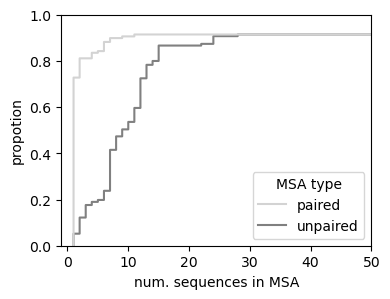

Mean gap fraction for unpaired MSAs between 10-30 sequences: 0.36568518029694486
Maximum gap fraction for unpaired MSAs between 10-30 sequences: 0.7594529364440867


In [8]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = alphafold_metadata_df.copy()

sns.ecdfplot(figure_df, hue='msa_type', x='msa_num_sequences', palette={'unpaired':'gray', 'paired':'lightgray'})


ax.set_xlim(xmin=-1, xmax=50)
ax.get_legend().set_title('MSA type')
ax.set_ylabel('propotion')
ax.set_xlabel('num. sequences in MSA')

plt.show()

# It is pretty clear that AlphaFold is not generating MSAs for many of the alignments. Even eith only 10 sequences, this would be better than 

filter_ = (alphafold_metadata_df.msa_type == 'unpaired')
filter_ = filter_ & (alphafold_metadata_df.msa_num_sequences < 30)
filter_ = filter_ & (alphafold_metadata_df.msa_num_sequences > 10)
print('Mean gap fraction for unpaired MSAs between 10-30 sequences:', alphafold_metadata_df[filter_].msa_mean_gap_fraction.mean())
print('Maximum gap fraction for unpaired MSAs between 10-30 sequences:', alphafold_metadata_df[filter_].msa_mean_gap_fraction.max())

# alphafold_metadata_df[filter_].dir_path.iloc[0]

# output = AlphaFoldOutput('/home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/bz_1_cluster_0_1mer-bz_1_cluster_2_1mer')
# print(output.get_msas()[1]['unpaired'])

In [11]:
MMSEQS_DIR = '../data/genes/mmseqs'
MMSEQS_DATABASE_DIR = '../data/genes/mmseqs/db'
MMSEQS_TMP_DIR = '../data/tmp'

@dataclass
class Databases:
    input: str
    output_search: str
    output_align: str
    output_msa: str

name = 'level_1_conserved_clusters'
databases = Databases(f'{MMSEQS_DATABASE_DIR}/{name}', f'{MMSEQS_DATABASE_DIR}/{name}.out', f'{MMSEQS_DATABASE_DIR}/{name}.aln', f'{MMSEQS_DATABASE_DIR}/{name}.msa')


def make_msas(path:str, databases=databases, output_dir_path:str=MMSEQS_DIR, sensitivity=9.5):
    '''Use MMseqs align utilities to construct a3m-format alignment files for each sequence in the input FASTA file. The pipeline
    is as follows:
        (1) Use the input FASTA file to construct an MMseqs database. 
        (2) Generate a search result database by querying the input database against itself. 
        (3) Construct full alignments using the results of the search. 
        (4) Convert the alignments to MSAs. 
        (5) Unpack the alignment output info a3m files compatible with AlphaFold; there will be one file per query.
        
    : param path: The path to the FASTA file containing all sequences to create MSAs for. 
    : param databases: The Databases dataclass containing the paths and names for all requisite intermediate MMseqs databases.    
    : param output_dir_path: The directory where all final a3m files will be deposited. 
    : param sensitivity: The search sensitivity for the initial MMseqs search step. 
    '''
    subprocess.run(f'mmseqs createdb {path} {databases.input}', shell=True, check=True)
    subprocess.run(f'mmseqs search {databases.input} {databases.input} {databases.output_search} {MMSEQS_TMP_DIR} -s {sensitivity}', shell=True, check=True)
    subprocess.run(f'mmseqs align {databases.input} {databases.input} {databases.output_search} {databases.output_align}', shell=True, check=True)
    subprocess.run(f'mmseqs result2msa {databases.input} {databases.input} {databases.output_align} {databases.output_msa}', shell=True, check=True)
    subprocess.run(f'mmseqs unpackdb {databases.output_msa} {output_dir_path} --unpack-suffix .a3m', shell=True, check=True)

    # The unpacked database files just have numerical IDs, so want to rename according to their actual gene IDs. 
    # This is done by mapping the numerical ID to the original gene ID using the lookup table associated with the input database. 
    num_to_gene_id_map = pd.read_csv(databases.input + '.lookup', sep=r'\s+', names=['num', 'gene_id'], index_col=0, usecols=[0, 1]).gene_id.to_dict()
    for file_name in os.listdir(output_dir_path):
        if not re.match(r'\d+\.a3m', file_name):
            continue 
        n = int(re.match(r'(\d+)\.a3m', file_name).group(1))
        old_path = os.path.join(output_dir_path, file_name)
        new_path = os.path.join(output_dir_path, f'{num_to_gene_id_map[n]}.a3m')
        subprocess.run(f'mv {old_path} {new_path}', shell=True, check=True)


def get_msas_unpaired(gene_ids:list, dir_path:str=MMSEQS_DIR):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    : param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    : param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
    '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
        (1) Loading the unpaired MSA for each query gene ID. 
        (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
        (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
    : param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    : param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
    msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

    genome_ids = None
    for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
        genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
    if len(genome_ids) < 2:
        # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
        print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

    sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
    msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
    return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}


make_msas('../data/genes/level_1_conserved_clusters.faa' )

# Clean up the created databases and folders.
for path in glob.glob(os.path.join(MMSEQS_DATABASE_DIR, '*')): 
    os.remove(path)
shutil.rmtree(MMSEQS_TMP_DIR, ignore_errors=True)


    

createdb ../data/genes/level_1_conserved_clusters.faa ../data/genes/mmseqs/db/level_1_conserved_clusters 

MMseqs Version:                    	18.8cc5c
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	16
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[
Time for merging to level_1_conserved_clusters_h: 0h 0m 0s 4ms
Time for merging to level_1_conserved_clusters: 0h 0m 0s 3ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 33ms
Create directory ../data/tmp
search ../data/genes/mmseqs/db/level_1_conserved_clusters ../data/genes/mmseqs/db/level_1_conserved_clusters ..

In [18]:
names = list()

for genome_id, df in genes_df.groupby('genome_id'):
    input = list()
    
    for pair in itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2):
        name = pair[0]['alphafold_gene_id'] + '-' + pair[1]['alphafold_gene_id']
        gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
        seqs = [pair[0]['seq'], pair[1]['seq']]

        names.append(name)

        msas = dict()
        msas['paired'] = get_msas_paired(gene_ids)
        msas['unpaired'] = get_msas_unpaired(gene_ids)

        file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=5)

        for gene_id, seq in zip(gene_ids, seqs):
            file.add_seq(seq, paired_msa=msas['paired'][gene_id], unpaired_msa=msas['unpaired'][gene_id])

        file_name = f'{name}.json'
        file.write(f'../data/genes/alphafold/af_input/{file_name}')
        
print(ALPHAFOLD_BIOTITE_CMD)
# print(ALPHAFOLD_BIOTITE_CMD.format(file_name=file_name))

# https://app.gitbook.com/o/-LzcB3BNVSNh_20MBLKi/s/-M-S5z_vnCqDzDHcfsmi/protein-folding

output_dirs = [os.path.join(ALPHAFOLD_OUTPUT_DIR, name) for name in names]
# assert np.all([os.path.isdir(path) for path in output_dirs]), 'Missing some of the expected output directories.'


sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir /root/af_input --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"


In [ ]:
gene_ids = sorted(genes_df.alphafold_gene_id.unique())
genome_ids = sorted(genes_df.genome_id.unique())
figure_df = pd.DataFrame(columns=gene_ids, index=gene_ids)

for dir_path in output_dirs:
    output = AlphaFoldOutput(dir_path)
    iptms = list(output.get_iptms().values())

    gene_ids = os.path.basename(dir_path).split('-')
    figure_df.loc[gene_ids[0], gene_ids[1]] = np.mean(iptms)
    figure_df.loc[gene_ids[1], gene_ids[0]] = np.mean(iptms)

figure_df = figure_df.fillna(0).astype(float)


FileNotFoundError: [Errno 2] No such file or directory: '../data/genes/alphafold/af_output/bz_0_cluster_8_1mer-bz_0_cluster_7_1mer/bz_0_cluster_8_1mer-bz_0_cluster_7_1mer_data.json'

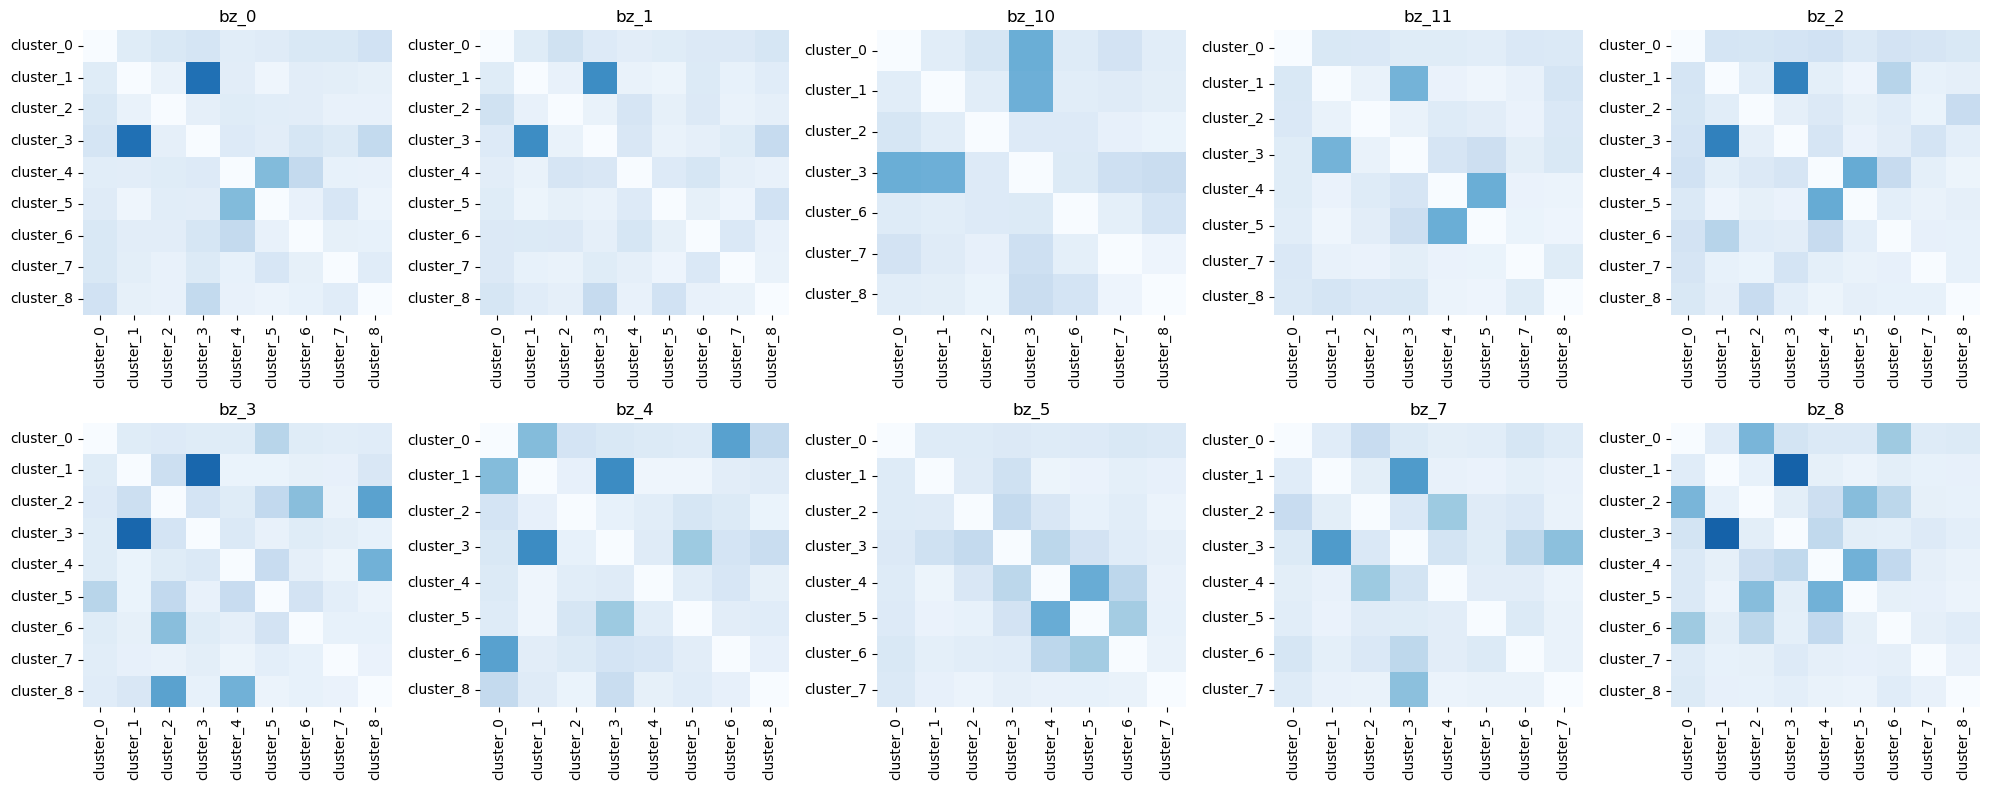

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))

for genome_id, ax in zip(genome_ids, axes.ravel()):
    idxs = np.where([get_genome_id(gene_id) == genome_id for gene_id in figure_df.index])[0]
    sns.heatmap(figure_df.iloc[idxs, idxs], cbar=False, ax=ax, cmap='Blues', vmin=0, vmax=1)
    
    x_tick_labels = [re.search(r'cluster_\d+', str(label)).group(0) for label in ax.get_xticklabels()]
    y_tick_labels = [re.search(r'cluster_\d+', str(label)).group(0) for label in ax.get_xticklabels()]
    ax.set_xticks(ax.get_xticks(), labels=x_tick_labels)
    ax.set_yticks(ax.get_yticks(), labels=y_tick_labels)
    ax.set_title(genome_id)

fig.tight_layout()
plt.show()

In [ ]:
# It seems as though the cluster_1-cluster_3 contact is only predicted highly with the cluster_3 monomer. But is this a failing of AlphaFold?
# Do the contacting residues differ between the monomer predictions and the multimer predictions (i.e. does cluster_3 multimerizing block 
# the preferred interface for cluster_1 and cluster_3)?